In [14]:
# Copyright (c) Meta Platforms, Inc. and affiliates.
# and David Edel
# This source code is licensed under the MIT license found in the
# LICENSE file in the root directory of this source tree.

"""Simple example of QAT using DDP (ResNet on CIFAR-10)
Adapted from https://github.com/akamaster/pytorch_resnet_cifar10"""
# os.environ["TORCH_LOGS"]="recompiles"
import torch
import torch._dynamo

torch._dynamo.config.cache_size_limit = 64
torch._dynamo.config.recompile_limit = 64
# torch._dynamo.config.verbose = True
# torch._inductor.config.debug = True

import json
import torch.nn as nn
from torch import optim

from model import resnet
from model.resnet import ResNet,BasicBlock
import wandb
import time


from tqpmod.parq_utils import (
    NORM_LAYERS,
    get_param_groups,
    split_param_groups,
    create_data_loaders,
)

from tqpmod.logging_utils import init_loger_and_folder
from tqpmod.train_eval import train_epoch, evaluate
import math # for nan check
DEVICE = torch.device("cuda:0")
torch.set_float32_matmul_precision("high")  # improves matmul speed
import matplotlib.pyplot as plt

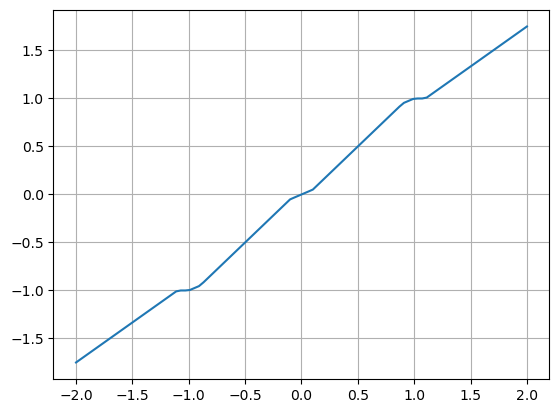

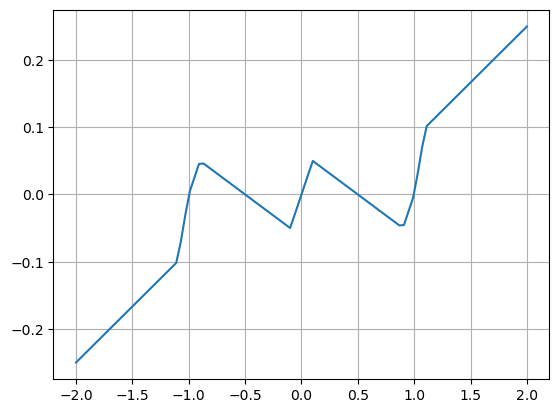

In [15]:
# redefining prox functions to include near zero identity interpolation

def piece_quad_prox_scale_layer_later_zero(params, beta,z = 1.0):
    if beta < 1.0:
        apply_prox_to_list_optim_scale_layer_later_zero(
            params,
            beta,
            z
        )
    else:
        apply_prox_hard_rounding_list_scale_layer(params, beta=beta)


@torch.compile()
@torch.no_grad()
def apply_prox_hard_rounding_list_scale_layer(params: torch.Tensor, beta):
    for param in params:
        param.clip_(-1.0, 1.0).round_()
        # param.copy_(apply_hard_rounding_ternary_scale_layer(param.data).detach())


@torch.compile()
@torch.no_grad()
def apply_prox_to_list_optim_scale_layer_later_zero(params, beta,z = 1.0):
    """
    assume beta < 1 and M = 1
    """
    for param in params:
        param.copy_(apply_prox_same_beta_optim_scale_layer_later_zero(param.data, beta,z = z).detach())


# @torch.compile(dynamic=False) #TODO compile
@torch.no_grad()
def apply_prox_same_beta_optim_scale_layer_later_zero(theta_old: torch.Tensor, beta: torch.Tensor,z = 1.0):
    # factor replaces the one
    # this means that factor * one = factor, which is where the slope will be 0 after the transformation
    """
    z = zero_zone_interpolation_factor
    assume beta < 1 and M = 1
    will handle every tensor row-wise, so (A,B,C) will be treated as (A,B*C)
    """

    theta_new = theta_old
    a0 = beta / 2
    abs_theta = abs(theta_new)
    y = torch.where(abs_theta < a0, 0, abs_theta / (1 - beta) - (1 / (1 - beta) * a0))
    # y[abs_theta>(1-a0)]=1
    y = torch.where(abs_theta > (1 - a0), 1, y)
    y = torch.where(
        abs_theta > 1 + a0, # outer edge
        abs_theta / (1 + beta) + (1 - ((1 + beta / 2) / (1 + beta))),
        y,
    )
    y = torch.where(abs_theta < 1.0,(z * y) + (1-z) * abs_theta ,y)
    return y * torch.sign(theta_new)

x = torch.linspace(-2.,2.,100)
y = apply_prox_same_beta_optim_scale_layer_later_zero(x,0.2,0.5)
plt.plot(x,y)
plt.grid()
plt.show()
plt.plot(x,x-y)
plt.grid()
plt.show()

In [16]:
# redefing the TQPS optimizer to allow passing of interpolation value
from typing import Iterable, Self
from torch.optim import Optimizer
import itertools
import logging
class TQPS(Optimizer):
    """
    TODO: make serializable, (savable, restoreable)

    """

    steps: int

    def __init__(
        self,
        base_optimizer: Optimizer,
        steps_per_epoch,
        reg_wait_epochs: int = 5,
        regularization_epochs=10,
        beta: float = 0,
        device=torch.device("cuda:0"),
        logger=logging.getLogger(__name__),
        reg_function_=piece_quad_prox_scale_layer_later_zero,
    ):
        self.reg_function_ = reg_function_
        self.logger = logger
        super().__init__(
            [{"params": []}], {"lr": base_optimizer.defaults["lr"]}
        )  # NOTE  check if params from base_optimizer should be placed here
        self.base_optimizer = base_optimizer
        self.beta = torch.tensor(
            1.0, requires_grad=False, device=device
        )  # gets overwritten below
        self.beta.mul_(beta)
        self.M = torch.tensor([1])
        self.state["steps"] = torch.zeros(
            (), requires_grad=False, device=torch.device("cpu")
        )
        self.steps_per_epoch = steps_per_epoch
        self.warmup_epochs = reg_wait_epochs
        self.total_steps = (regularization_epochs + reg_wait_epochs) * steps_per_epoch
        self.total_reg_steps = regularization_epochs * steps_per_epoch
        self.step_start_reg = reg_wait_epochs * steps_per_epoch

        # self.beta = next(self.beta_schedule)
        self.regularized_params: list[torch.Tensor] = []
        for group in self.get_regularized_param_groups():
            self.regularized_params.extend(
                group["params"]
            )  # append all reg parms to list for efficient
        #     # iteration later in compiled functions
        #     for param in group["params"]:
        #         # lets hope the ordering of this stays the same
        #         self.state["factors"].append(torch.ones((param.shape[0],1), device=device))
        # self.row_levels_inverse.append(
        #     torch.ones((param.shape[0],), device=device)
        # )  # this is a inverse_levels tensor,
        # matricies get multiplied x * W^T, so the first dim of W is the amount of rows.
        # so for each matrix (for now only 2d weights), this will give each row( the weights for one neuron) a level.
        # The Quantization targets for this row will be {-level, 0, level}
        # when quantizing for real, multiply the row by 1/ level, and the bias by 1/ level
        #  scaling neurons will be inserted after the linear layer with a value of level.
        self.param_groups = self.base_optimizer.param_groups
        self.z = 1.0

    def is_quantization_enabled(self):
        if self.state["steps"] <= self.step_start_reg:  # <= because we increment in
            # step before calling into here
            return False
        return True

    def get_regularized_param_groups(self):
        for group in self.base_optimizer.param_groups:
            if group.get("quant_bits", 16) < 16:
                yield group

    def set_z(self,z):
        self.z = z

    def set_final_beta(self):
        """
        sets all following betas to 1 and disables requires_grad on regParams
        """
        self.beta_schedule = itertools.repeat(1.0)
        self.beta = 1.0
        for param in self.regularized_params:
            param.requires_grad = (
                False  # is will disable gradient descent, but this will most likely
            )
            # not change anything, because beta is now 1 and hard rounding gets used.

    def step(self: Self):
        """
        does not accept a closure yet!
        """
        self.state["steps"] += 1
        self.base_optimizer.step()
        if not self.is_quantization_enabled():
            return  # do stuff as normal
        else:
            pass  # continues with prox operator
        # print("STEPPING WITH PROX")
        # define map (per tensor later, or per channel, row etc.)
        # abs(param) > M map will always be needed
        # but based on beta <> 1 we should make different maps
        reg_step = self.state["steps"] - self.step_start_reg
        warmup_factor = min(1, (reg_step / self.steps_per_epoch) / 50) # assumes 10 epochs for beta warmup are available
        # print(warmup_factor)
        # does increase local performance, but probably not global (later in training) performance
        self.reg_function_(self.regularized_params, self.beta * warmup_factor,self.z)


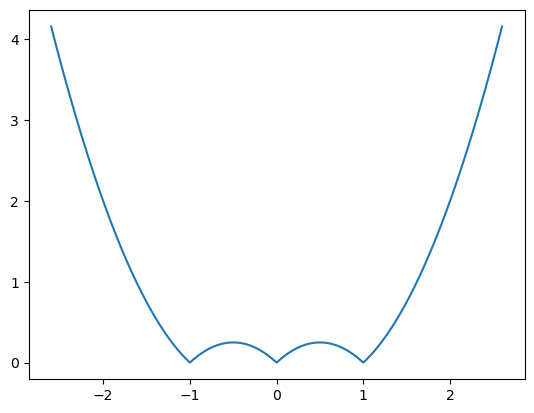

In [17]:
class SoftBinningScale:
    def __init__(self, bins=3):
        if bins < 3 or bins % 2 != 1:
            raise ValueError("bins must be odd >= 3")
        self.bins = bins // 2
        self.max = self.bins

    @torch.no_grad()
    @torch.compile()
    def call_test(self, x: torch.Tensor):
        x = torch.abs(x)
        y = 1 - self.max + x
        mask = x < self.max
        y[mask] = x[mask] - torch.floor(x[mask])
        y = y * torch.abs(1 - y)
        return y

    def compute_xright_quantile(self, x: torch.Tensor):
        x, _ = x.clone().detach().flatten().sort()
        third = x[x.shape[0] // 3]
        two_thirds = x[int(x.shape[0] * (2 / 3))]
        return third.abs() + two_thirds.abs()


soft_binning = SoftBinningScale(3)
x = torch.linspace(-2.6,2.6,1000)
y = soft_binning.call_test(x)
plt.plot(x,y)


In [18]:
@torch.compile()
@torch.no_grad()
def calc_reg_loss_scale_layer(
    optimizer:TQPS,
    soft_binning: SoftBinningScale,
    n_params,
    device=torch.device("cuda:0"),
    M=1,
    beta=5e-4,
    compute_per_layer_share_done = False
):
    """
    returns tuple of:
    avg_reg_loss, a norm, %done
    """

    reg_loss = torch.zeros((), device=device, requires_grad=False)
    quantized_params = torch.zeros(
        (), device=device, requires_grad=False, dtype=torch.int64
    )
    norm = torch.zeros((), device=device, requires_grad=False)
    per_layer_share_done = torch.zeros((len(optimizer.regularized_params)))
    for i, param in enumerate(optimizer.regularized_params):
        
        reg_loss += soft_binning.call_test(param).sum().detach()

        calc_param = param.detach()
        quantized_this_param = (
            (abs(calc_param - calc_param.round().clip(-M, M)) < (beta / 2))
            .sum()
            .to(torch.int64))
        quantized_params += quantized_this_param
        
        per_layer_share_done[i] = quantized_this_param / param.numel()
        norm += param.norm().detach()

    return (reg_loss / n_params).item(), norm.sqrt().item(), (quantized_params / n_params).item(), per_layer_share_done

@torch.no_grad()
def factor_function_test(params):
    return (params.flatten().std() * 2 * 0.5) * torch.ones((params.shape[0],),device=params.device)
    # the 0.5 and 2 cancel, but leave them in because we could adjust the params for this

In [19]:
import numpy as np
from tqpmod.model_utils import inject_scale_layers, rebalance_layers
from typing import Any, Callable


def longrun_scale_layer(
    beta, train_params: dict[str, Any], run_name: str = "ScaleLayerTrain"
):
    try:
        logger, folder = init_loger_and_folder(run_name)
        history = {
            "train_loss": [],
            "train_acc": [],
            "test_loss": [],
            "test_acc": [],
            "reg_loss": [],
            "norm": [],
            "per_layer_share_done": [],
            "beta": [],
        }

        # ALL these hyperparams could get overwritten by train_params
        num_epochs = 600  # 1000  # like 310
        num_epochs_lr_schedule = 599  # 999 # 300
        learning_rate = 0.1
        weight_decay = 2e-4

        lr_warmup_epochs = 10
        percentage_new_cos = 0.1
        new_cos_epoch = (num_epochs - lr_warmup_epochs) / 2  # gets overwritten below

        REG_wait_epochs = 55  # 55
        rebalance_wait_epochs = 35
        SEED = torch.randint(0, 10000, (1,))
        batch_size = 64

        inject_scales = True

        if train_params is not None:
            num_epochs = train_params.get("num_epochs", num_epochs)
            num_epochs_lr_schedule = num_epochs - 1
            num_epochs_lr_schedule = train_params.get(
                "num_epochs_lr_schedule", num_epochs_lr_schedule
            )
            learning_rate = train_params.get("learning_rate", learning_rate)
            weight_decay = train_params.get("weight_decay", weight_decay)
            lr_warmup_epochs = train_params.get("lr_warmup_epochs", lr_warmup_epochs)
            percentage_new_cos = train_params.get(
                "percentage_new_cos", percentage_new_cos
            )
            new_cos_epoch = (
                num_epochs - lr_warmup_epochs
            ) / 2  # Overwrite default based on provided params
            new_cos_epoch = train_params.get("new_cos_epoch", new_cos_epoch)
            REG_wait_epochs = train_params.get("REG_wait_epochs", REG_wait_epochs)
            rebalance_wait_epochs = train_params.get("rebalance_wait_epochs",rebalance_wait_epochs) 
            SEED = train_params.get("SEED", SEED)

            batch_size = train_params.get("batch_size", batch_size)

            inject_scales = train_params.get("inject_scales", inject_scales)

        torch.manual_seed(SEED)

        train_loader, val_loader = create_data_loaders(
            "~/data",
            batch_size,
            11,
            False,
            SEED,
        )
        steps_per_epoch = len(train_loader)

        z_schedule_tensor = torch.zeros((num_epochs,))
        threeforths_epochs = int(num_epochs / 2 * 1)
        z_schedule_tensor[threeforths_epochs:]= torch.linspace(0,1e0,num_epochs - threeforths_epochs)
        z_schedule = iter(z_schedule_tensor)
        # define loss function (criterion) and optimizer
        scaler = torch.amp.GradScaler("cuda")
        label_smoothing = 0.1
        criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing).to(DEVICE)  #
        model = ResNet(BasicBlock, [3, 3, 3], skip_kaiming_init=True)
        param_groups = []
        # TOD:
        rest_group = []
        names = {
            param: name for name, param in model.named_parameters()
        }  # for debugging

        if inject_scales:
            inject_scale_layers(
                model,
                param_groups,
                factor_function=factor_function_test,
                learning_rate=learning_rate,
                weight_decay=weight_decay,
                scale_grad=False,
            )
        else: # disables scale train
            param_groups.append(
                {
                    "params": [param for param in model.parameters() if len(param.shape) > 1],
                    "quant_bits": 32,
                    "weight_decay": weight_decay,
                    "learning_rate": learning_rate,
                }
            )

        model = model.to(DEVICE)
        # specify number of quantization bits for different parameter groups

        # None indicates that it will need to get updated before starting training
        # param_groups_quant = [{"params:":[param],"quant_bits":0,"weight_decay": None,learning_rate:None} for param in params_quant]
        param_groups_list = []
        for param_group in param_groups:
            param_groups_list.extend([id(param) for param in param_group["params"]])

        for name, param in model.named_parameters():
            if id(param) not in param_groups_list:
                rest_group.append(param)
        param_groups.append(
            {
                "params": rest_group,
                "weight_decay": 0,
                "lr": learning_rate,
            }  # use defalut lr
        )

        def build_lr_factor(lr_warmup_epochs, num_epochs_lr_schedule=None):
            num_epochs_lr_schedule = num_epochs_lr_schedule or (num_epochs - 1)

            def get_lr_factor(epoch):
                if epoch < lr_warmup_epochs:
                    return (epoch + 1) / lr_warmup_epochs
                elif epoch > num_epochs_lr_schedule:
                    return get_lr_factor(num_epochs_lr_schedule)
                else:
                    return max(
                        [
                            0.5
                            * (
                                1
                                + np.cos(
                                    np.pi
                                    * (epoch - lr_warmup_epochs)
                                    / (num_epochs_lr_schedule - lr_warmup_epochs)
                                )
                            ),
                            1e-9,
                        ]
                    )

            return get_lr_factor

        get_lr_factor: Callable = build_lr_factor(
            lr_warmup_epochs, num_epochs_lr_schedule
        )

        base_optimizer = torch.optim.SGD(
            param_groups,
            learning_rate,
            momentum=0.9,
            weight_decay=weight_decay,
            fused=True,  # test
        )
        lr_scheduler = optim.lr_scheduler.LambdaLR(
            base_optimizer, lr_lambda=get_lr_factor
        )

        best_acc = 0.0
        best_reg_loss = float("inf")

        optimizer = TQPS(
            base_optimizer,
            len(train_loader),
            reg_wait_epochs=REG_wait_epochs,
            regularization_epochs=num_epochs,
            beta=beta,
            logger=logger,
        )
        optimizer.base_optimizer.zero_grad()

        n_reg_params = sum([torch.numel(x) for x in optimizer.regularized_params])
        model = torch.compile(model, mode="max-autotune", fullgraph=True, dynamic=False)
        torch.save(
            {
                "epoch": 0,
                "num_epochs": num_epochs,
                "SEED": SEED,
                "label_smoothing": label_smoothing,
                "REG_wait_epochs": REG_wait_epochs,
                "lr_warmup_epochs": lr_warmup_epochs,
                "num_epochs_lr_schedule": num_epochs_lr_schedule,
                "model_state_dict": model.state_dict(),
                "base_optimizer_state_dict": base_optimizer.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "current_acc": 0,
                "reg_loss": torch.inf,
                "lr_schedule": lr_scheduler.state_dict(),
                "scaler": scaler.state_dict(),
                "history": json.dumps(history),
                "best_reg_loss": best_reg_loss,
                "best_acc": best_acc,
                "batch_size": batch_size,
            },
            f"{folder}/init_pre_train.pth",
        )
        with wandb.init(
            project="ResNet-TQP",
            name=f"{run_name}-{beta}",
            config={
                "architecture": "ResNet20",
                "load_state": False,
                "Use Pretrained": f"{False}",
                "dataset": "CIFAR-10",
                "seed": SEED,
                "num_epochs": num_epochs,
                "batch_size": batch_size,
                "optimizer": base_optimizer.__class__.__name__,
                "start_lr": learning_rate,
                "lr_warmup_epochs": lr_warmup_epochs,
                "weight_decay": weight_decay,
                "beta": beta,
                "reg_wait_epochs": REG_wait_epochs,
                "label_smoothing": label_smoothing,
                "note": "every epoch factor, dont wait",
            },
            # mode="disabled"
        ) as run:

            for epoch in range(0, num_epochs):
                # for epoch in range(start_epoch, 350):
                # for epoch in range(num_epochs, num_epochs+20):
                start_time = time.time()
                logger.info(
                    f"\nEpoch [{epoch+1}/{num_epochs}] | LR: {base_optimizer.param_groups[0]['lr']:.10f}"
                )

                if epoch == num_epochs - 1:
                    optimizer.set_final_beta()
                    logger.warning("DISABLED GRAD ON REG-PARAMS")
                    logger.info("overwrote beta to 1 for final epoch")

                z = next(z_schedule) # interpolation value near zero
                optimizer.set_z(z)

                # Train
                train_loss, train_acc = train_epoch(
                    model,
                    train_loader,
                    criterion,
                    optimizer,
                    scaler,
                    DEVICE,
                    epoch == 10,
                    epoch,
                    amp=True,
                )
                # TODO: compute change rate

                
                # keep REBALANCE_LAYERS and LR_SCHEDULER.STEP together, because we need to avoid training after rebalancing before updating learning rates
                if epoch == rebalance_wait_epochs - 1:  # TODO: check one off error
                #if epoch > 0:
                    param_dict = {
                        group["params"][0]: {"index": index, "group": group}
                        for index, group in enumerate(optimizer.param_groups)
                        if len(group["params"]) == 1
                    }
                    # param_dict is needed because rebalance needs to know each parameter_groups index in the lr_schedulers base_lrs list.
                    # the group itself is also needed to adjust weight decay.
                    rebalance_layers(
                        model,
                        param_dict,
                        lr_scheduler,
                        optimizer,
                        factor_function=factor_function_test,
                    )
                lr_scheduler.step()

                # TODO: think about wd decay with scaled again!!
                # for param_group in optimizer.get_regularized_param_groups():
                #     param_group["weight_decay"] = weight_decay * get_lr_factor(epoch)

                reg_loss, norm, share_done,per_layer_share_done = calc_reg_loss_scale_layer(
                    optimizer, soft_binning, n_reg_params, beta=beta
                )
                # decay beta based on finished_rate
                if epoch > 11 and optimizer.beta != 1.0:
                    new_beta = (1 - share_done) * beta + share_done * (beta * 1e-2)
                    new_beta = min(new_beta, history["beta"][-1])
                    if isinstance(optimizer.beta, torch.Tensor):
                        optimizer.beta.copy_(new_beta)
                    else:
                        optimizer.beta = torch.tensor(
                            new_beta, device=DEVICE, requires_grad=False
                        )
                else:
                    new_beta = beta
                # Save history
                history["beta"].append(new_beta)
                history["train_loss"].append(train_loss)
                history["train_acc"].append(train_acc)

                history["per_layer_share_done"].append(per_layer_share_done.detach().cpu().numpy().tolist())
                logger.info(
                    f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Reg Loss: {reg_loss:.4f}"
                )

                history["reg_loss"].append(reg_loss)
                history["norm"].append(norm)

                to_log = {
                    "lr": torch.tensor(lr_scheduler.get_last_lr()).mean().item(),
                    "epoch": epoch,
                    "train_loss": train_loss,
                    "train_acc": train_acc,
                    "reg_loss": reg_loss,
                    "norm": norm,
                    "beta": optimizer.beta,
                    "share_done": share_done,
                    "z": z
                }

                if epoch % 2 == 1:
                    test_loss, test_acc = evaluate(model, val_loader, criterion, DEVICE)
                    history["test_acc"].append(test_acc)
                    history["test_loss"].append(test_loss)
                    logger.info(
                        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%"
                    )
                    to_log.update(
                        {
                            "test_loss": test_loss,
                            "test_acc": test_acc,
                        }
                    )
                    best_acc = max([test_acc, best_acc])

                    # to_log.update({f"change_rate_layer_{i}": cr for i, cr in enumerate(change_rates)})

                    # Save best model
                    if reg_loss < best_reg_loss:
                        best_reg_loss = reg_loss
                        torch.save(
                            {
                                "epoch": epoch,
                                "num_epochs": num_epochs,
                                "SEED": SEED,
                                "label_smoothing": label_smoothing,
                                "REG_wait_epochs": REG_wait_epochs,
                                "lr_warmup_epochs": lr_warmup_epochs,
                                "num_epochs_lr_schedule": num_epochs_lr_schedule,
                                "model_state_dict": model.state_dict(),
                                "base_optimizer_state_dict": base_optimizer.state_dict(),
                                "optimizer_state_dict": optimizer.state_dict(),
                                "current_acc": test_acc,
                                "reg_loss": reg_loss,
                                "lr_schedule": lr_scheduler.state_dict(),
                                "scaler": scaler.state_dict(),
                                "history": json.dumps(history),
                                "best_reg_loss": best_reg_loss,
                                "best_acc": best_acc,
                                "batch_size": batch_size,
                            },
                            f"{folder}/best_reg_loss_model.pth",
                        )
                        logger.info(
                            f"✓ Saved best model with best reg_loss: {best_reg_loss:.3f}, accuracy: {test_acc:.2f}%"
                        )
                    else:
                        logger.info(
                            f"(X) model did not beat reg_loss: {reg_loss:.3f} vs {best_reg_loss:.3f}, accuracy: {test_acc:.2f}%"
                        )
                    # health check:
                    if math.isnan(reg_loss):
                        raise RuntimeError("idk why but reg loss in nan")
                epoch_time = time.time() - start_time
                logger.info(f"Epoch Time: {epoch_time:.2f}s")
                to_log.update({"epoch time:": epoch_time})
                run.log(to_log, step=epoch)
            # wandb context
            # if epoch == 10:
            #     break
    except Exception as e:
        logger.error(f"error: {e}")
    return history, model, optimizer

In [20]:
hist, model, optimizer = longrun_scale_layer(
    5e-4, {"num_epochs": 300, "REG_wait_epochs": 15,"rebalance_wait_epochs":15}, "test"
)

2026-06-17 21:26:07 [WARNING] Starting logging...
/home/david/miniconda3/envs/torch26/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


2026-06-17 21:26:09 [INFO] 
Epoch [1/300] | LR: 0.7542691231
Training: 100%|██████████| 781/781 [00:20<00:00, 37.39it/s] 
2026-06-17 21:26:31 [INFO] Train Loss: 1.6796 | Train Acc: 44.78% | Reg Loss: 0.3983
2026-06-17 21:26:31 [INFO] Epoch Time: 21.65s
2026-06-17 21:26:31 [INFO] 
Epoch [2/300] | LR: 1.5085382462
Training: 100%|██████████| 781/781 [00:03<00:00, 215.02it/s]
2026-06-17 21:26:35 [INFO] Train Loss: 1.3776 | Train Acc: 60.52% | Reg Loss: 0.5962
Evaluating: 100%|██████████| 157/157 [00:07<00:00, 21.14it/s]
2026-06-17 21:26:42 [INFO] Test Loss: 1.3701 | Test Acc: 63.80%
2026-06-17 21:26:42 [INFO] ✓ Saved best model with best reg_loss: 0.596, accuracy: 63.80%
2026-06-17 21:26:42 [INFO] Epoch Time: 11.09s
2026-06-17 21:26:42 [INFO] 
Epoch [3/300] | LR: 2.2628073692
Training: 100%|██████████| 781/781 [00:03<00:00, 209.93it/s]
2026-06-17 21:26:46 [INFO] Train Loss: 1.2160 | Train Acc: 69.02% | Reg Loss: 0.9017
2026-06-17 21:26:46 [INFO] Epoch Time: 3.73s
2026-06-17 21:26:46 [INFO]

beta,████████████████████████████████▇▇▇▆▄▃▂▁
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
epoch time:,▂▁▄▃▁▂▂▄▄▁▄▂▅▄▂▁▁▂▃▁▃█▅▄▅██████▇▇▇▇██▇▅▄
lr,▂▆▇█▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
norm,█▄▄▄▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
reg_loss,▂▃▆█▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
share_done,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂█
test_acc,▁▃▅▆▆▅▆▅▆▅▅▆▆▆▅▅▆▆▆▆▇▇▆▇▇▇▇█████████████
test_loss,█▅▅▅▅▅▅▅▄▅▄▄▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇███████
+2,...


In [ ]:
for i in range(10):
    hist, model, optimizer = longrun_scale_layer(
        5e-4, {"num_epochs": 300, "REG_wait_epochs": 35}, "z0_value_near_allowed"
    )

In [ ]:
share_done = hist["per_layer_share_done"]
shares_done = np.array(share_done)
print(shares_done.shape)
plt.plot(shares_done)
for i in range(shares_done.shape[1]):
    print(shares_done[-1,i])

In [ ]:
epochs = [{"num_epochs":100, "REG_wait_epochs":15}, {"num_epochs":200, "REG_wait_epochs":35}, {"num_epochs":500, "REG_wait_epochs":45}, {"num_epochs":2000, "REG_wait_epochs":80}]
for config in epochs:
    start_i = 0 if config["num_epochs"] != 100 else 4
    for i in range(start_i,5):
        hist, model,optimizer = longrun_scale_layer(5e-4,config,f"COMP_NoDoubleCos_{config["num_epochs"]}_{i}")

hist, model,optimizer = longrun_scale_layer(5e-4,{"num_epochs":8000, "REG_wait_epochs":100},f"COMP_NoDoubleCos_{8000}_{0}")

In [ ]:
for param in optimizer.param_groups[-1]["params"]:
    print(param.shape)

In [ ]:
hist, model,optimizer = longrun_scale_layer(5e-4,{},"long2k-reg")

In [ ]:
res = []
for i in range(5):
    res_once = {}
    for beta in [1e-2,5e-3,1e-3,5e-4,1e-4]:
        hist, model, optimizer = longrun_scale_layer(beta,"test_betDec_fix_momReb_test_lritem_no_betaschedule")
        res_once[beta]= hist
    res.append(res_once)

In [ ]:
betas = res[0].keys()
for beta in betas:
    accs = [res[i][beta]["test_acc"][-1] for i in range(len(res))]
    print(beta,accs,torch.tensor(accs).mean().item(),torch.tensor(accs).var().item())

print(beta,accs,torch.tensor(accs).mean().item(),torch.tensor(accs).var().item())

0.01 [90.33, 90.55, 90.15, 90.52, 90.53] 90.41600036621094 0.029979677870869637 

0.005 [91.03, 90.67, 90.71, 90.72, 90.32] 90.69000244140625 0.06354987621307373 

0.001 [91.74, 91.44, 91.7, 91.69, 91.86] 91.68599700927734 0.023479677736759186 

0.0005 [92.15, 91.92, 91.42, 91.87, 91.59] 91.78999328613281 0.0824509710073471 

0.0001 [91.57, 91.29, 91.52, 91.51, 91.58] 91.49400329589844 0.013929947279393673

In [ ]:
hist, model,optimizer = longrun_scale_layer(8e-4,"fixed-netadecay")

In [ ]:
train_loader, val_loader = create_data_loaders(
            "~/data",
            64,
            0,
            False,
            32,
            debug=False
        )
# param_dict = {group["params"][0]:group for group in optimizer.param_groups if len(group["params"])==1 }
criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(DEVICE)  #
print(evaluate(model._orig_mod,val_loader,criterion,DEVICE))
# rebalance_layers(model,param_dict,factor_function=factor_function_test)
print(evaluate(model,val_loader,criterion,DEVICE))

In [ ]:
dir(model.conv1)

In [ ]:
names = {param:name for name,param in model.named_parameters()}

In [ ]:
for param_group in optimizer.param_groups:
    name = [names[param_group["params"][i]] for i in range(len(param_group["params"]))]
    print(name,param_group.get("weight_decay",0),param_group.get("lr",0),param_group.get("weight_decay",0) * param_group.get("lr",0) )
    print()

In [ ]:
model.linear[1].scale.mean()

In [ ]:

plt.hist(model.conv1[0].weight.detach().cpu().flatten(),bins = 40)


In [ ]:
model2 = ResNet(BasicBlock, [3, 3, 3], skip_kaiming_init=True)
inject_scale_layers(model2,[])
model2 = model2.to(DEVICE)
model2 = torch.compile(model2)
model2.load_state_dict(model.state_dict())

In [ ]:
from tqdm import tqdm
def evaluate(model, loader, criterion, device,transform_train_x_dtype = torch.float32, amp=False):
    model.eval()
    running_loss = torch.zeros((), device=device, requires_grad=False)
    correct = torch.zeros((), device=device, requires_grad=False)
    total = 0

    pbar = tqdm(loader, desc="Evaluating")
    for images, labels in pbar:
        torch.compiler.cudagraph_mark_step_begin() # probably not needed
        images: torch.Tensor
        labels: torch.Tensor
        images, labels = images.to(device,transform_train_x_dtype, non_blocking=True), labels.to(
            device, non_blocking=True
        )
        with torch.amp.autocast("cuda",enabled=amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        running_loss += loss.detach()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().detach()
        total += labels.size(0)

    avg_loss = running_loss.item() / len(loader)
    test_accuracy = 100.0 * correct.item() / total
    return avg_loss, test_accuracy

In [ ]:
train_loader, val_loader = create_data_loaders(
            "~/data",
            128,
            11,
            False,
            32,
            debug=False
        )

In [ ]:
print("Testing: fp32_orig_mod ,fp32, fp32amp, bfp16")
criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(DEVICE)  #
model2 = ResNet(BasicBlock, [3, 3, 3], skip_kaiming_init=True)
inject_scale_layers(model2,[])
model2 = model2.to(DEVICE)
model2 = torch.compile(model2)
model2:ResNet
model2.load_state_dict(model.state_dict())
print(evaluate(model2._orig_mod,val_loader,criterion,DEVICE))
# rebalance_layers(model,param_dict,factor_function=factor_function_test)
print(evaluate(model2,val_loader,criterion,DEVICE))
print(evaluate(model2,val_loader,criterion,DEVICE,amp=True))
model2 = model2.to(torch.bfloat16)
print(evaluate(model2,val_loader,criterion,DEVICE,transform_train_x_dtype=torch.bfloat16))


In [ ]:
print("Testing: fp32, fp32amp, fp16")
criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(DEVICE)  #
model2 = ResNet(BasicBlock, [3, 3, 3], skip_kaiming_init=True)
inject_scale_layers(model2,[])
model2 = model2.to(DEVICE)
model2 = torch.compile(model2)
model2:ResNet
model2.load_state_dict(model.state_dict())
print(evaluate(model2,val_loader,criterion,DEVICE))
print(evaluate(model2,val_loader,criterion,DEVICE,amp=True))
model2 = model2.to(torch.float16)
print(evaluate(model2._orig_mod,val_loader,criterion,DEVICE,transform_train_x_dtype=torch.float16))


In [ ]:
print("Testing: fp8_per_tensor_scale, fp8_per_row_scale")
from torchao.quantization import (
    Float8DynamicActivationFloat8WeightConfig,
    PerRow,
    PerTensor,
    quantize_,
)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(DEVICE)  #
model2 = ResNet(BasicBlock, [3, 3, 3], skip_kaiming_init=True)
inject_scale_layers(model2,[])
model2 = model2.to(DEVICE)
model2 = torch.compile(model2)
model2:ResNet
model2.load_state_dict(model.state_dict())
quantize_(model2, Float8DynamicActivationFloat8WeightConfig(granularity=PerTensor()))

print(evaluate(model2,val_loader,criterion,DEVICE,transform_train_x_dtype=torch.float16))

model2 = ResNet(BasicBlock, [3, 3, 3], skip_kaiming_init=True)
inject_scale_layers(model2,[])
model2 = model2.to(DEVICE)
model2 = torch.compile(model2)
model2:ResNet
model2.load_state_dict(model.state_dict())
quantize_(model2, Float8DynamicActivationFloat8WeightConfig(granularity=PerRow()))
print(evaluate(model2,val_loader,criterion,DEVICE,transform_train_x_dtype=torch.float16))

In [ ]:
print("Testing: int8_weight_only, int4_weight_only, int2_weight_only")
from torchao.quantization import (
    Float8DynamicActivationFloat8WeightConfig,
    PerRow,
    PerTensor,
    quantize_,Int8WeightOnlyConfig,Int4WeightOnlyConfig,IntxWeightOnlyConfig
)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(DEVICE)  #

model2 = ResNet(BasicBlock, [3, 3, 3], skip_kaiming_init=True)
inject_scale_layers(model2,[])
model2 = model2.to(DEVICE)
model2 = torch.compile(model2)
model2:ResNet
model2.load_state_dict(model.state_dict())
quantize_(model2, Int8WeightOnlyConfig())
print(evaluate(model2,val_loader,criterion,DEVICE,transform_train_x_dtype=torch.float16))

model2 = ResNet(BasicBlock, [3, 3, 3], skip_kaiming_init=True)
inject_scale_layers(model2,[])
model2 = model2.to(DEVICE)
model2 = torch.compile(model2)
model2:ResNet
model2.load_state_dict(model.state_dict())
quantize_(model2, Int4WeightOnlyConfig())
print(evaluate(model2,val_loader,criterion,DEVICE,transform_train_x_dtype=torch.float16))

model2 = ResNet(BasicBlock, [3, 3, 3], skip_kaiming_init=True)
inject_scale_layers(model2,[])
model2 = model2.to(DEVICE)
model2 = torch.compile(model2)
model2:ResNet
model2.load_state_dict(model.state_dict())
quant_config = IntxWeightOnlyConfig(weight_dtype=torch.int2)
quantize_(model2, quant_config)
print(evaluate(model2,val_loader,criterion,DEVICE,transform_train_x_dtype=torch.float16))